In [1]:
import time
import torch
import tensorflow as tf
import psutil

class PowerMonitor:
    def __init__(self):
        self.gpu_available = tf.config.list_physical_devices('GPU')
        
        # Hardware power specifications (adjust these values for your system)
        self.cpu_tdp = 65    # Typical TDP for desktop CPUs in watts
        self.gpu_tdp = 250   # Typical TDP for desktop GPUs in watts
        
    def get_stats(self):
        """Get system stats with power estimation"""
        stats = {
            'timestamp': time.time(),
            'cpu_%': psutil.cpu_percent(interval=0.1),
            'ram_mb': psutil.virtual_memory().used / (1024**2),
            'gpu_mem_mb': 0,
            'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85  # Base CPU power
        }
        
        if self.gpu_available:
            try:
                # TensorFlow GPU memory monitoring
                mem_info = tf.config.experimental.get_memory_info('GPU:0')
                stats.update({
                    'gpu_mem_mb': mem_info['current'] / (1024**2),
                    'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85 + 
                              self.gpu_tdp * 0.5 * 0.75  # Add GPU power estimate
                })
            except:
                pass
                
        return stats

# Initialize monitor
monitor = PowerMonitor()

c:\Users\aneek\anaconda3\envs\tf_gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


def build_meso4_model(input_shape=(160, 160, 3)):
    """
    Meso-4 architecture adapted to the standardized benchmark.

    Initialization:
        Random initialization

    Input:
        uint8 OpenCV BGR images

    Labels:
        0 = real
        1 = fake
    """

    inputs = layers.Input(
        shape=input_shape,
        dtype=tf.uint8,
        name="input_images"
    )

    # OpenCV images: BGR -> RGB
    x = layers.Lambda(
        lambda image: tf.reverse(
            tf.cast(image, tf.float32),
            axis=[-1]
        ),
        name="bgr_to_rgb"
    )(inputs)

    # Normalize [0, 255] -> [0, 1]
    x = layers.Rescaling(
        scale=1.0 / 255.0,
        name="meso4_preprocessing"
    )(x)

    # Block 1
    x = layers.Conv2D(
        8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="block1_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block1_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block1_pool"
    )(x)

    # Block 2
    x = layers.Conv2D(
        8,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block2_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block2_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block2_pool"
    )(x)

    # Block 3
    x = layers.Conv2D(
        16,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block3_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block3_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block3_pool"
    )(x)

    # Block 4
    x = layers.Conv2D(
        16,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block4_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block4_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(4, 4),
        padding="same",
        name="block4_pool"
    )(x)

    # Official-style classifier structure
    x = layers.Flatten(
        name="flatten"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout_1"
    )(x)

    x = layers.Dense(
        16,
        name="dense_16"
    )(x)

    # Use alpha for compatibility with older Keras versions
    x = layers.LeakyReLU(
        alpha=0.1,
        name="leaky_relu"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout_2"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Meso4_Deepfake_Detector"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model


model = build_meso4_model(
    input_shape=(160, 160, 3)
)

model.summary()

print(
    "\nTrainable parameters:",
    sum(
        tf.keras.backend.count_params(variable)
        for variable in model.trainable_weights
    )
)

Model: "Meso4_Deepfake_Detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 bgr_to_rgb (Lambda)         (None, 160, 160, 3)       0         
                                                                 
 meso4_preprocessing (Rescal  (None, 160, 160, 3)      0         
 ing)                                                            
                                                                 
 block1_conv (Conv2D)        (None, 160, 160, 8)       224       
                                                                 
 block1_batchnorm (BatchNorm  (None, 160, 160, 8)      32        
 alization)                                                      
                                                                 
 block1_pool (MaxPooling2D)  (None, 80, 80,

# Wild deepfake

In [3]:
import h5py
import numpy as np

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

with h5py.File(H5_PATH, "r") as h5f:
    # Load image arrays
    train_images = h5f["train_images"][:]
    train_labels = h5f["train_labels"][:]

    val_images = h5f["val_images"][:]
    val_labels = h5f["val_labels"][:]

    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

# Verify dataset sizes
print(f"Total train: {len(train_images)} images")
print(f"Total validation: {len(val_images)} images")
print(f"Total test: {len(test_images)} images")

print(f"Train labels: {len(train_labels)}")
print(f"Validation labels: {len(val_labels)}")
print(f"Test labels: {len(test_labels)}")

# Verify shapes and data types
print("\nArray information:")
print(f"Train images: {train_images.shape}, dtype={train_images.dtype}")
print(f"Validation images: {val_images.shape}, dtype={val_images.dtype}")
print(f"Test images: {test_images.shape}, dtype={test_images.dtype}")

print(f"Train labels: {train_labels.shape}, dtype={train_labels.dtype}")
print(f"Validation labels: {val_labels.shape}, dtype={val_labels.dtype}")
print(f"Test labels: {test_labels.shape}, dtype={test_labels.dtype}")

# Verify class distributions
print("\nClass distribution:")
print(
    f"Train: Real={np.sum(train_labels == 0)}, "
    f"Fake={np.sum(train_labels == 1)}"
)
print(
    f"Validation: Real={np.sum(val_labels == 0)}, "
    f"Fake={np.sum(val_labels == 1)}"
)
print(
    f"Test: Real={np.sum(test_labels == 0)}, "
    f"Fake={np.sum(test_labels == 1)}"
)

Total train: 36000 images
Total validation: 6000 images
Total test: 18000 images
Train labels: 36000
Validation labels: 6000
Test labels: 18000

Array information:
Train images: (36000, 160, 160, 3), dtype=uint8
Validation images: (6000, 160, 160, 3), dtype=uint8
Test images: (18000, 160, 160, 3), dtype=uint8
Train labels: (36000,), dtype=uint8
Validation labels: (6000,), dtype=uint8
Test labels: (18000,), dtype=uint8

Class distribution:
Train: Real=9000, Fake=27000
Validation: Real=1500, Fake=4500
Test: Real=4500, Fake=13500


In [4]:

# Train model
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
2250/2250 [==============================] - 22s 8ms/step - loss: 0.7814 - accuracy: 0.6713 - precision: 0.7611 - recall: 0.8188 - roc_auc: 0.5467 - pr_auc: 0.7745 - val_loss: 0.5305 - val_accuracy: 0.7497 - val_precision: 0.7509 - val_recall: 0.9969 - val_roc_auc: 0.6984 - val_pr_auc: 0.8841
Epoch 2/100
2250/2250 [==============================] - 18s 8ms/step - loss: 0.6007 - accuracy: 0.7111 - precision: 0.7586 - recall: 0.9019 - roc_auc: 0.5850 - pr_auc: 0.8059 - val_loss: 0.5157 - val_accuracy: 0.7503 - val_precision: 0.7505 - val_recall: 0.9993 - val_roc_auc: 0.7264 - val_pr_auc: 0.8963
Epoch 3/100
2250/2250 [==============================] - 18s 8ms/step - loss: 0.5659 - accuracy: 0.7314 - precision: 0.7614 - recall: 0.9349 - roc_auc: 0.6224 - pr_auc: 0.8284 - val_loss: 0.5057 - val_accuracy: 0.7500 - val_precision: 0.7500 - val_recall: 1.0000 - val_roc_auc: 0.7334 - val_pr_auc: 0.8987
Epoch 4/100
2250/2250 [==============================] - 18s 8ms/step - loss: 0.54

In [5]:
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

1125/1125 [==============================] - 4s 3ms/step - loss: 0.6833 - accuracy: 0.7361 - precision: 0.8313 - recall: 0.8132 - roc_auc: 0.7365 - pr_auc: 0.8778

Test results:
loss: 0.6833
accuracy: 0.7361
precision: 0.8313
recall: 0.8132
roc_auc: 0.7365
pr_auc: 0.8778


save the model

In [6]:
import tensorflow as tf

# After training the model
model.save('Mesonet_160_wild100.h5')  # Saves the entire model to a file

In [7]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_wilddeepfake_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
D:\thesis\results\Mesonet_wilddeepfake_10epochs.h5


In [ ]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [10]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_wild100.h5")

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Load only the test split
with h5py.File(H5_PATH, "r") as h5f:
    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

print("Model loaded")
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Model loaded
Test images: (18000, 160, 160, 3)
Test labels: (18000,)


In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

In [ ]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts

Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


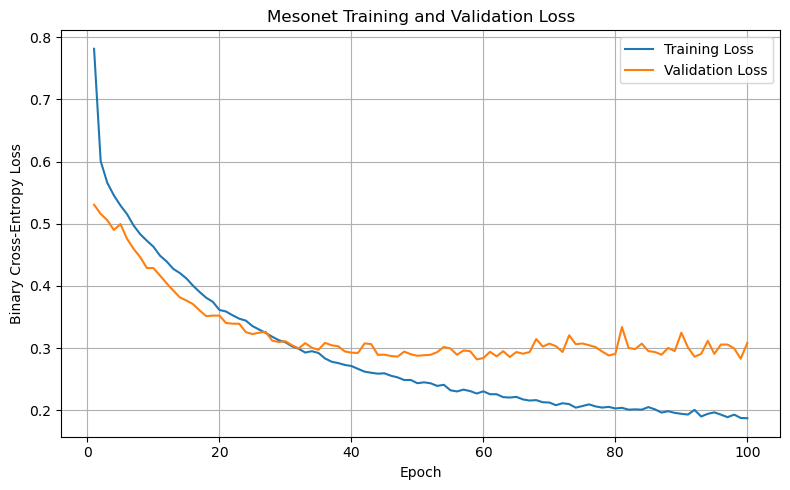

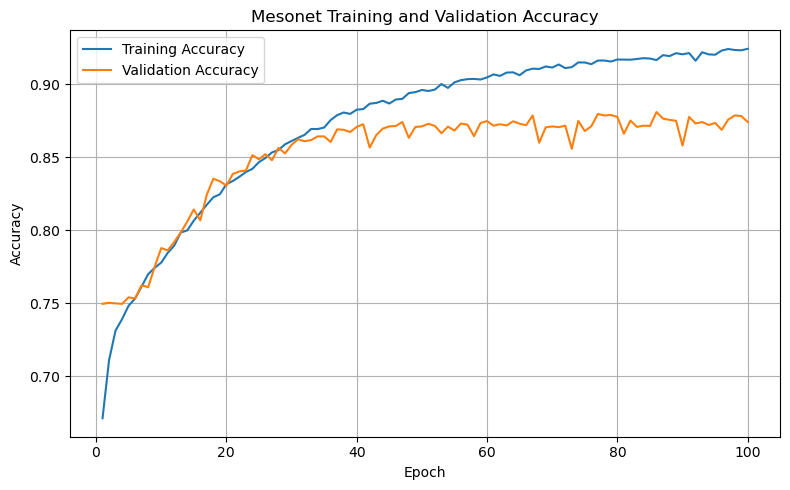

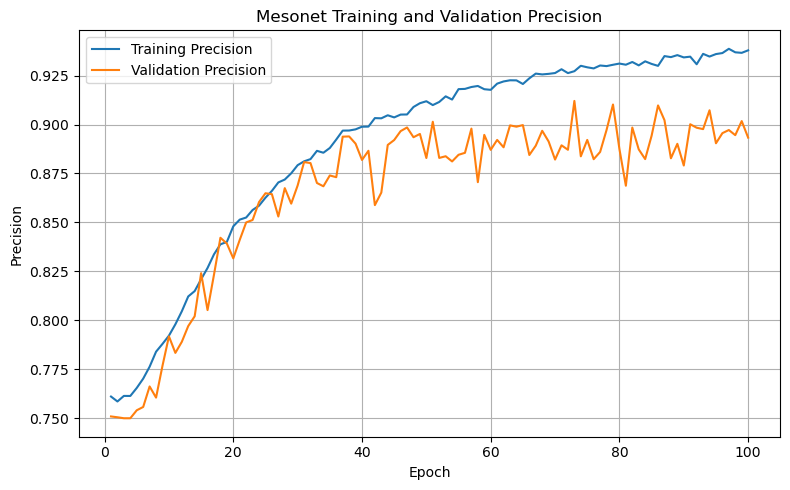

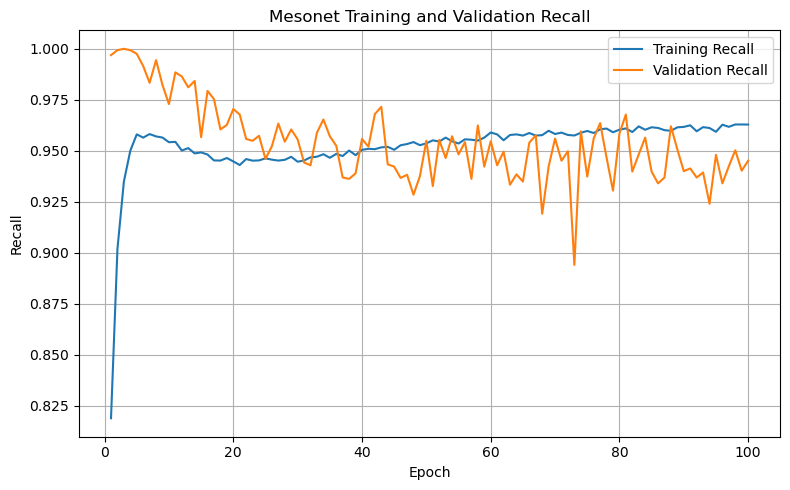

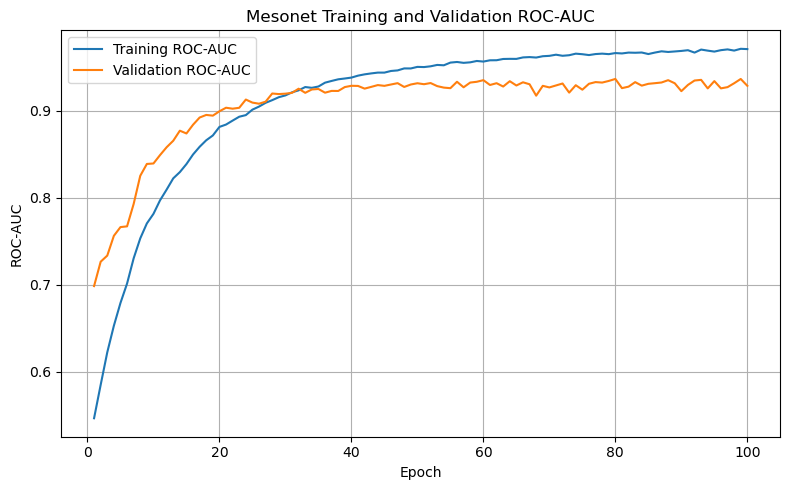

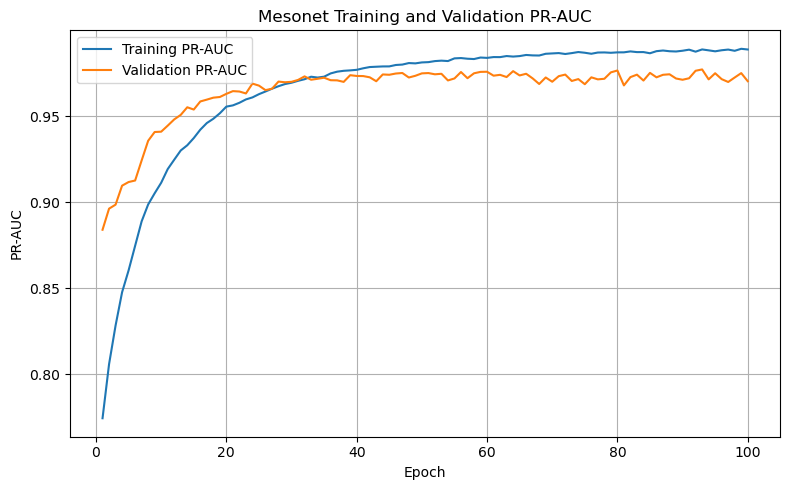

In [16]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_images),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_images[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_images,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_images)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_15344\2159758100.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 2.90 seconds, 0.1614 ms/image

Starting resource run 2/5
Run 2: 2.60 seconds, 0.1445 ms/image

Starting resource run 3/5
Run 3: 2.62 seconds, 0.1458 ms/image

Starting resource run 4/5
Run 4: 2.63 seconds, 0.1463 ms/image

Starting resource run 5/5
Run 5: 2.52 seconds, 0.1398 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,2.904549,0.161364,6197.175747,3.711250,5.375000,8312.113281,9526.710469,9671.011719,1214.597187,1358.898438,...,7183.226562,7183.226562,0.0,0.0,56.880000,100,36.967120,69.788,0.028701,1
1,2.600199,0.144456,6922.546550,4.333203,6.718750,8353.074219,9560.176432,9709.960938,1207.102214,1356.886719,...,7183.226562,7183.226562,0.0,0.0,63.625000,100,37.956208,60.517,0.026911,2
2,2.623611,0.145756,6860.773186,4.781771,27.465625,8354.125000,9563.844238,9711.492188,1209.719238,1357.367188,...,7183.226562,7183.226562,0.0,0.0,62.958333,100,39.845333,58.761,0.027176,3
3,2.633235,0.146291,6835.698555,3.956771,9.156250,8354.746094,9561.624512,9712.492188,1206.878418,1357.746094,...,7183.226562,7183.226562,0.0,0.0,60.541667,95,36.171208,59.623,0.025985,4
4,2.515652,0.139758,7155.202422,4.000781,6.659375,8356.054688,9563.294271,9712.835938,1207.239583,1356.781250,...,7183.226562,7183.226562,0.0,0.0,61.166667,81,36.839083,59.187,0.026081,5


In [8]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,2.655449,0.146760,2.473223,2.837675
1,latency_ms_per_image,0.147525,0.008153,0.137401,0.157649
2,throughput_images_per_s,6794.279292,356.856985,6351.182821,7237.375763
3,average_cpu_percent,4.156755,0.413695,3.643085,4.670426
4,peak_cpu_percent,11.075000,9.264163,-0.427977,22.577977
5,average_ram_mb,9555.129984,15.952337,9535.322542,9574.937427
6,peak_ram_mb,9703.558594,18.228475,9680.924953,9726.192235
7,average_incremental_ram_mb,1209.107328,3.278337,1205.036735,1213.177922
8,peak_incremental_ram_mb,1357.535938,0.854413,1356.475044,1358.596831
9,average_gpu_memory_mb,7183.226562,0.000000,7183.226562,7183.226562



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.148 ± 0.008 (95% CI: 0.137–0.158)
peak_ram_mb: 9703.559 ± 18.228 (95% CI: 9680.925–9726.192)
peak_gpu_memory_mb: 7183.227 ± 0.000 (95% CI: 7183.227–7183.227)
average_gpu_utilization_percent: 61.034 ± 2.643 (95% CI: 57.753–64.315)
average_gpu_power_w: 37.556 ± 1.430 (95% CI: 35.780–39.331)


In [9]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_images,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_images,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

1125/1125 [==============================] - 2s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     18000
Decision threshold:         0.5000
Test loss:                  0.683253

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.736111 (73.61%)
Precision:                  0.831289 (83.13%)
Recall/Sensitivity:         0.813185 (81.32%)
F1-score:                   0.822137 (82.21%)
ROC-AUC:                    0.736968
PR-AUC:                     0.881263
Average Precision:          0.881272
EER:                        0.321556 (32.16%)
EER threshold:              0.683949

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.659037
Specificity:                0.504889
Matthews correlation:       0.311578
False-positive rate @ 0.5:  0.495111
False-negative rate @ 0.5:  0.186815

Confusion matrix
------------------

genralization

In [11]:
#celeb on wilddeepfake
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on Celeb-DF(V2) (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 2s 5ms/step - loss: 2.1965 - accuracy: 0.3176 - precision: 0.9045 - recall: 0.2742 - roc_auc: 0.5081 - pr_auc: 0.9065

Test results of wild deepfake dataset on Celeb-DF(V2) (Mesonet):
loss: 2.1965
accuracy: 0.3176
precision: 0.9045
recall: 0.2742
roc_auc: 0.5081
pr_auc: 0.9065


In [13]:
#dfc on wilddeepfake

test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on DFC (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 2s 7ms/step - loss: 1.5106 - accuracy: 0.4997 - precision: 0.4996 - recall: 0.4420 - roc_auc: 0.5089 - pr_auc: 0.4858

Test results of wild deepfake dataset on DFC (Mesonet):
loss: 1.5106
accuracy: 0.4997
precision: 0.4996
recall: 0.4420
roc_auc: 0.5089
pr_auc: 0.4858


In [15]:
#ff++ on wilddeepfake

test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on FF++ (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 1s 5ms/step - loss: 1.6021 - accuracy: 0.5503 - precision: 0.4177 - recall: 0.2017 - roc_auc: 0.4781 - pr_auc: 0.4128

Test results of wild deepfake dataset on FF++ (Mesonet):
loss: 1.6021
accuracy: 0.5503
precision: 0.4177
recall: 0.2017
roc_auc: 0.4781
pr_auc: 0.4128


# Celeb

In [10]:
import os
import cv2
import numpy as np

SAVE_ROOT = r'D:\thesis\celeb_processed'

def load_split(split_name, class_name):
    """Reload saved frames, grouped by video."""
    base = os.path.join(SAVE_ROOT, split_name, class_name)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        vid_dir = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(vid_dir, f))
                  for f in sorted(os.listdir(vid_dir))]
        if frames:
            nested.append(frames)
            ids.append(vid_id)
    return nested, ids

# Reload ALL six splits
print("Loading frames...")
real_train_final,  real_train_ids  = load_split('train', 'real')
synth_train_final, synth_train_ids = load_split('train', 'fake')
real_val_final,    real_val_ids    = load_split('val',   'real')
synth_val_final,   synth_val_ids   = load_split('val',   'fake')
real_test_final,   real_test_ids   = load_split('test',  'real')
synth_test_final,  synth_test_ids  = load_split('test',  'fake')

print("✅ All frames reloaded")
print("Train -> real videos:", len(real_train_final), " fake videos:", len(synth_train_final))
print("Val   -> real videos:", len(real_val_final),   " fake videos:", len(synth_val_final))
print("Test  -> real videos:", len(real_test_final),  " fake videos:", len(synth_test_final))
print("Example frame shape:", np.shape(real_train_final[0][0]))  # expect (160,160,3)
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Flatten video-grouped frames into one image array and create labels.

    real_videos: list of videos, where each video is a list of frames
    fake_videos: list of videos, where each video is a list of frames

    Returns
    -------
    images : NumPy array with shape (N, 160, 160, 3)
    labels : NumPy array with shape (N,)
             0 = real, 1 = fake
    """

    # Flatten frames from all real videos
    real_frames = [
        frame
        for video_frames in real_videos
        for frame in video_frames
        if frame is not None
    ]

    # Flatten frames from all fake videos
    fake_frames = [
        frame
        for video_frames in fake_videos
        for frame in video_frames
        if frame is not None
    ]

    if len(real_frames) == 0:
        raise ValueError("No real frames were found.")

    if len(fake_frames) == 0:
        raise ValueError("No fake frames were found.")

    # Convert to NumPy arrays
    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    # Combine images
    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    # Create labels
    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training set
train_celeb, train_labels = combine_split(
    real_train_final,
    synth_train_final
)

# Validation set
val_celeb, val_labels = combine_split(
    real_val_final,
    synth_val_final
)

# Testing set
test_celeb, test_labels = combine_split(
    real_test_final,
    synth_test_final
)
print("\nTRAIN")
print("Images:", train_celeb.shape)
print("Labels:", train_labels.shape)
print("Real:", np.sum(train_labels == 0))
print("Fake:", np.sum(train_labels == 1))

print("\nVALIDATION")
print("Images:", val_celeb.shape)
print("Labels:", val_labels.shape)
print("Real:", np.sum(val_labels == 0))
print("Fake:", np.sum(val_labels == 1))

print("\nTEST")
print("Images:", test_celeb.shape)
print("Labels:", test_labels.shape)
print("Real:", np.sum(test_labels == 0))
print("Fake:", np.sum(test_labels == 1))

print("\nData types")
print("Train images:", train_celeb.dtype)
print("Train labels:", train_labels.dtype)

Loading frames...
✅ All frames reloaded
Train -> real videos: 354  fake videos: 3383
Val   -> real videos: 59  fake videos: 563
Test  -> real videos: 177  fake videos: 1693
Example frame shape: (160, 160, 3)

TRAIN
Images: (11899, 160, 160, 3)
Labels: (11899,)
Real: 1142
Fake: 10757

VALIDATION
Images: (1969, 160, 160, 3)
Labels: (1969,)
Real: 182
Fake: 1787

TEST
Images: (5961, 160, 160, 3)
Labels: (5961,)
Real: 571
Fake: 5390

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_celeb, train_labels,
    validation_data=(val_celeb, val_labels),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
744/744 [==============================] - 12s 10ms/step - loss: 0.4860 - accuracy: 0.8620 - precision: 0.9041 - recall: 0.9479 - roc_auc: 0.5040 - pr_auc: 0.9056 - val_loss: 0.3142 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5654 - val_pr_auc: 0.9118
Epoch 2/100
744/744 [==============================] - 7s 9ms/step - loss: 0.3864 - accuracy: 0.8926 - precision: 0.9043 - recall: 0.9855 - roc_auc: 0.5162 - pr_auc: 0.9085 - val_loss: 0.3090 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5849 - val_pr_auc: 0.9144
Epoch 3/100
744/744 [==============================] - 7s 9ms/step - loss: 0.3716 - accuracy: 0.8949 - precision: 0.9040 - recall: 0.9887 - roc_auc: 0.5239 - pr_auc: 0.9121 - val_loss: 0.3067 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.6049 - val_pr_auc: 0.9230
Epoch 4/100
744/744 [==============================] - 7s 9ms/step - loss: 0.3561 - accur

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 2s 5ms/step - loss: 0.3234 - accuracy: 0.9037 - precision: 0.9042 - recall: 0.9994 - roc_auc: 0.5704 - pr_auc: 0.9235

Test results:
loss: 0.3234
accuracy: 0.9037
precision: 0.9042
recall: 0.9994
roc_auc: 0.5704
pr_auc: 0.9235



In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 16.1%
RAM Used: 711.5 MB
Time Usage: 4.2 s
GPU Memory Used: 1452.6 MB
Power Consumption: 93W


In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_celeb,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


373/373 [==============================] - 1s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     5961
Decision threshold:         0.5000
Test loss:                  0.3234

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.9037 (90.37%)
Precision:                  0.9042 (90.42%)
Recall/Sensitivity:         0.9994 (99.94%)
F1-score:                   0.9494 (94.94%)
ROC-AUC:                    0.5704
PR-AUC:                     0.9235
Average Precision:          0.9235
EER:                        0.452079 (45.21%)
EER threshold:              0.870798

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.4997
Specificity:                0.0000
Matthews correlation:      -0.0073
False-positive rate @ 0.5:  1.0000
False-negative rate @ 0.5:  0.0006

Confusion matrix
----------------------------------------------

save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_celeb_100epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_celeb.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_celeb_100epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


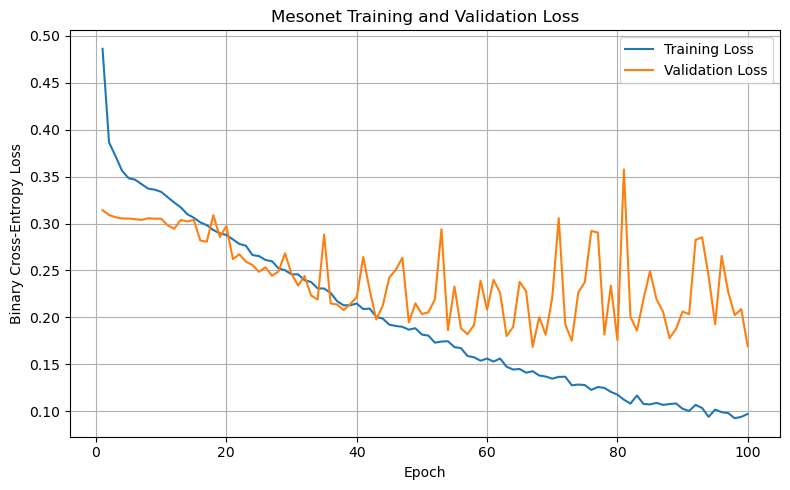

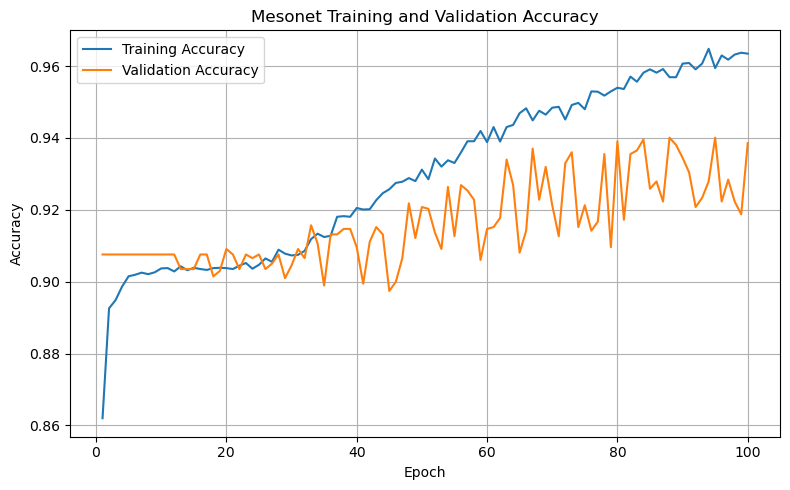

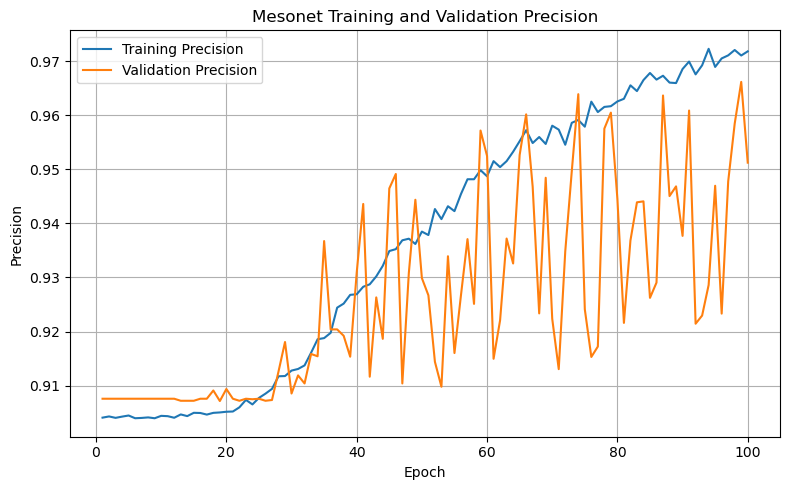

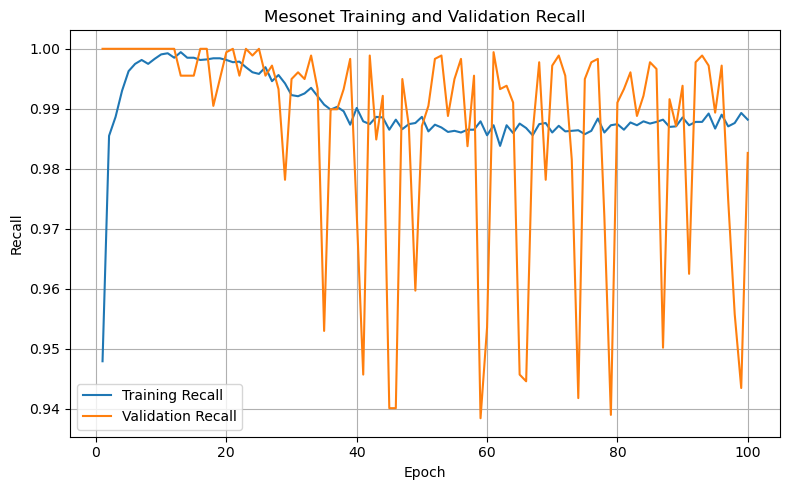

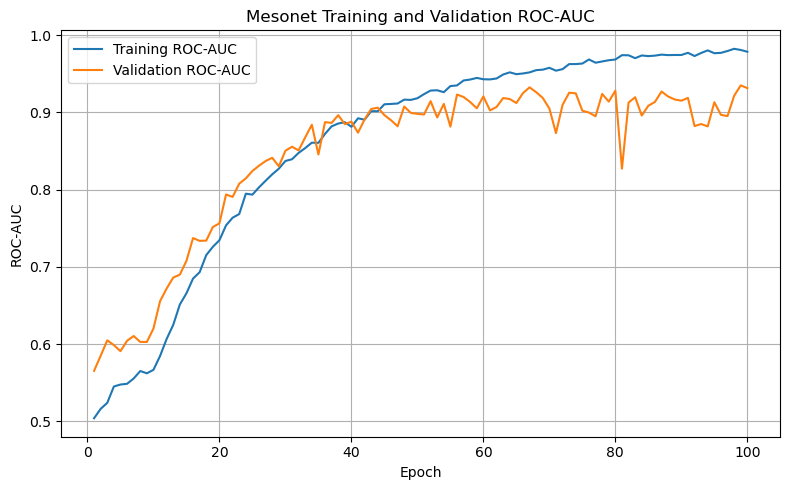

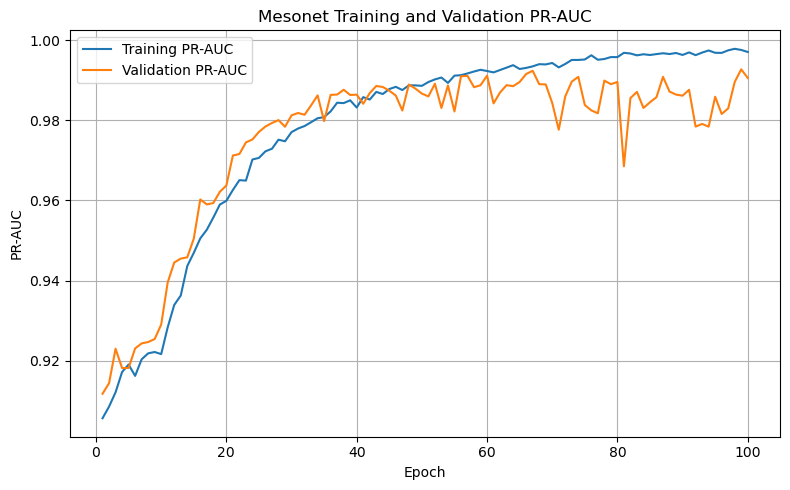

In [18]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_celeb.h5")


In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_celeb),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_celeb[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_celeb,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_celeb)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_20428\3984712684.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 1.31 seconds, 0.2199 ms/image

Starting resource run 2/5
Run 2: 1.22 seconds, 0.2044 ms/image

Starting resource run 3/5
Run 3: 1.06 seconds, 0.1770 ms/image

Starting resource run 4/5
Run 4: 1.12 seconds, 0.1874 ms/image

Starting resource run 5/5
Run 5: 1.08 seconds, 0.1809 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,1.310677,0.219875,4548.031979,3.602885,8.878125,6780.683594,7176.503906,7259.332031,395.820312,478.648438,...,7183.1875,7183.1875,0.0,0.0,52.692308,77,16.957692,41.748,0.005066,1
1,1.218660,0.204439,4891.437334,2.910795,4.884375,6797.343750,7174.149858,7272.390625,376.806108,475.046875,...,7183.1875,7183.1875,0.0,0.0,62.181818,94,16.717182,40.135,0.004548,2
2,1.055326,0.177038,5648.493162,3.589489,6.234375,6798.296875,7176.587358,7273.351562,378.290483,475.054688,...,7183.1875,7183.1875,0.0,0.0,55.000000,80,14.945545,38.055,0.003672,3
3,1.117040,0.187391,5336.425793,3.230682,4.478125,6798.609375,7178.784091,7273.644531,380.174716,475.035156,...,7183.1875,7183.1875,0.0,0.0,64.181818,100,16.484636,40.048,0.003953,4
4,1.078561,0.180936,5526.807892,3.010511,4.884375,6799.304688,7179.355469,7274.320312,380.050781,475.015625,...,7183.1875,7183.1875,0.0,0.0,62.727273,89,14.367909,41.126,0.003138,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,1.156053,0.106655,1.023623,1.288482
1,latency_ms_per_image,0.193936,0.017892,0.171720,0.216152
2,throughput_images_per_s,5190.239232,459.988687,4619.087840,5761.390624
3,average_cpu_percent,3.268872,0.320463,2.870965,3.666780
4,peak_cpu_percent,5.871875,1.807055,3.628119,8.115631
5,average_ram_mb,7177.076136,2.076170,7174.498231,7179.654041
6,peak_ram_mb,7270.607813,6.341414,7262.733907,7278.481718
7,average_incremental_ram_mb,382.228480,7.723473,372.638521,391.818439
8,peak_incremental_ram_mb,475.760156,1.614665,473.755284,477.765028
9,average_gpu_memory_mb,7183.187500,0.000000,7183.187500,7183.187500



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.194 ± 0.018 (95% CI: 0.172–0.216)
peak_ram_mb: 7270.608 ± 6.341 (95% CI: 7262.734–7278.482)
peak_gpu_memory_mb: 7183.188 ± 0.000 (95% CI: 7183.188–7183.188)
average_gpu_utilization_percent: 59.357 ± 5.148 (95% CI: 52.964–65.749)
average_gpu_power_w: 15.895 ± 1.160 (95% CI: 14.454–17.335)


#genralization

In [13]:
#wild deepfake on celeb
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 4s 4ms/step - loss: 1.5407 - accuracy: 0.6426 - precision: 0.7694 - recall: 0.7474 - roc_auc: 0.5578 - pr_auc: 0.7752

Test results of Celeb-DF(V2) on wild deepfake dataset (Mesonet):
loss: 1.5407
accuracy: 0.6426
precision: 0.7694
recall: 0.7474
roc_auc: 0.5578
pr_auc: 0.7752


In [15]:
#DFC on celeb
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on DFC dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



188/188 [==============================] - 1s 5ms/step - loss: 8.0396 - accuracy: 0.4967 - precision: 0.4983 - recall: 0.9620 - roc_auc: 0.5066 - pr_auc: 0.5037

Test results of Celeb-DF(V2) on DFC dataset (Mesonet):
loss: 8.0396
accuracy: 0.4967
precision: 0.4983
recall: 0.9620
roc_auc: 0.5066
pr_auc: 0.5037


In [17]:
#FF++ on celeb
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of Celeb-DF(V2) on FF++ dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 1s 4ms/step - loss: 2.5787 - accuracy: 0.5531 - precision: 0.4808 - recall: 0.9088 - roc_auc: 0.7124 - pr_auc: 0.5902  

Test results of Celeb-DF(V2) on FF++ dataset (Mesonet):
loss: 2.5787
accuracy: 0.5531
precision: 0.4808
recall: 0.9088
roc_auc: 0.7124
pr_auc: 0.5902


# DFC

In [12]:
import h5py
import numpy as np
# Open the HDF5 file in read mode
with h5py.File('D://thesis//dataset//deepfake dataset//resized_images.h5', 'r') as h5f:
    # Access each dataset
    celeb = np.array(h5f['celeb'])
    ffhq = np.array(h5f['ffhq'])
    gdwct = np.array(h5f['gdwct'])
    attgan = np.array(h5f['attgan'])
    stargan = np.array(h5f['stargan'])
    stylegan2 = np.array(h5f['stylegan2'])
    stylegan = np.array(h5f['stylegan'])

# Now, 'celeb', 'ffhq', etc., are NumPy arrays containing your datasets
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"ffhq shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"ffhq shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"ffhq shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"ffhq shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"ffhq shape: {stylegan.shape}, dtype: {stylegan.dtype}")
# Repeat for other datasets as needed
import cv2
# Function to resize images from (224, 224) to (160, 160)
def resize_images(image_array, target_size=(160, 160)):
    resized_images = np.array([cv2.resize(img, target_size) for img in image_array])
    return resized_images

celeb = resize_images(celeb, target_size=(160, 160))
ffhq = resize_images(ffhq, target_size=(160, 160))
gdwct = resize_images(gdwct, target_size=(160, 160))
attgan = resize_images(attgan, target_size=(160, 160))
stargan = resize_images(stargan, target_size=(160, 160))
stylegan = resize_images(stylegan, target_size=(160, 160))
stylegan2 = resize_images(stylegan2, target_size=(160, 160))
import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(celeb)), 2500)  # Get 2500 random indices
celeb = celeb[random_indices]  # Select the random subse

import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(ffhq)), 2500)  # Get 2500 random indices
ffhq = ffhq[random_indices]  # Select the random subse
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"gdwct shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"attagan shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"stargan shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"stylegan2 shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"stylegan shape: {stylegan.shape}, dtype: {stylegan.dtype}")
import random
import numpy as np

def split_data(data, train_ratio=0.7):
    """
    Splits data into training and testing sets based on the specified ratio.

    Parameters:
        data (list or np.array): The dataset to split.
        train_ratio (float): The ratio of the data to include in the training set.

    Returns:
        tuple: Two datasets - train and test.
    """
    # Shuffle the data
    random.shuffle(data)

    # Calculate the split index
    split_index = int(len(data) * train_ratio)

    # Split the data
    train_data = data[:split_index]
    test_data = data[split_index:]

    return train_data, test_data

# Split `celeb` into 70% train and 30% test
celeb_train_hog, celeb_test_hog = split_data(celeb, train_ratio=0.7)

# Split `ffhq` into 70% train and 30% test
ffhq_train_hog, ffhq_test_hog = split_data(ffhq, train_ratio=0.7)

# Split `attgan` into 70% train and 30% test
attgan_train_hog, attgan_test_hog = split_data(attgan, train_ratio=0.7)

# Split `stargan` into 70% train and 30% test
stargan_train_hog, stargan_test_hog = split_data(stargan, train_ratio=0.7)

# Split `gdwct` into 70% train and 30% test
gdwct_train_hog, gdwct_test_hog = split_data(gdwct, train_ratio=0.7)

# Split `stylegan2` into 70% train and 30% test_hog
stylegan2_train_hog, stylegan2_test_hog = split_data(stylegan2, train_ratio=0.7)

# Split `stylegan` into 70% train and 30% test_hog
stylegan_train_hog, stylegan_test_hog = split_data(stylegan, train_ratio=0.7)

# Convert to NumPy arrays if needed
celeb_train_hog, celeb_test_hog = np.array(celeb_train_hog), np.array(celeb_test_hog)
ffhq_train_hog, ffhq_test_hog = np.array(ffhq_train_hog), np.array(ffhq_test_hog)
attgan_train_hog, attgan_test_hog = np.array(attgan_train_hog), np.array(attgan_test_hog)
stargan_train_hog, stargan_test_hog = np.array(stargan_train_hog), np.array(stargan_test_hog)
gdwct_train_hog, gdwct_test_hog = np.array(gdwct_train_hog), np.array(gdwct_test_hog)
stylegan2_train_hog, stylegan2_test_hog = np.array(stylegan2_train_hog), np.array(stylegan2_test_hog)
stylegan_train_hog, stylegan_test_hog = np.array(stylegan_train_hog), np.array(stylegan_test_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_test: {len(celeb_test_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_test: {len(ffhq_test_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_test: {len(attgan_test_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_test: {len(stargan_test_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_test: {len(gdwct_test_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_test: {len(stylegan2_test_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_test: {len(stylegan_test_hog)} images")

########################################################################################################################################
#######################################divide into 60,10 train and val
#########################################################################################################################################
def extract_validation(train_data):
    """
    Extract every 10th sample from the training data and store it in a validation set.

    Parameters:
        train_data (list or np.array): The training dataset.

    Returns:
        tuple: Updated training dataset and validation dataset.
    """
    # Select every 10th sample for the validation set
    validation_data = train_data[::10]

    # Remove the selected samples from the training dataset
    updated_train_data = [train_data[i] for i in range(len(train_data)) if i % 10 != 0]

    return np.array(updated_train_data), np.array(validation_data)


# Perform the operation for each dataset
celeb_train_hog, celeb_val_hog = extract_validation(celeb_train_hog)
ffhq_train_hog, ffhq_val_hog = extract_validation(ffhq_train_hog)
attgan_train_hog, attgan_val_hog = extract_validation(attgan_train_hog)
stargan_train_hog, stargan_val_hog = extract_validation(stargan_train_hog)
gdwct_train_hog, gdwct_val_hog = extract_validation(gdwct_train_hog)
stylegan2_train_hog, stylegan2_val_hog = extract_validation(stylegan2_train_hog)
stylegan_train_hog, stylegan_val_hog = extract_validation(stylegan_train_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_val: {len(celeb_val_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_val: {len(ffhq_val_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_val: {len(attgan_val_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_val: {len(stargan_val_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_val: {len(gdwct_val_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_val: {len(stylegan2_val_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_val: {len(stylegan_val_hog)} images")
############################################################################################################################################################
#################################################concatenate the labels 0,1 real and fake
#############################################################################################################################################################


celeb_train_labels = np.zeros(len(celeb_train_hog), dtype=int)
ffhq_train_labels = np.zeros(len(ffhq_train_hog), dtype=int)
atta_train_labels = np.ones(len(attgan_train_hog), dtype=int)
star_train_labels = np.ones(len(stargan_train_hog), dtype=int)
gdwct_train_labels = np.ones(len(gdwct_train_hog), dtype=int)
stylegan2_train_labels = np.ones(len(stylegan2_train_hog), dtype=int)
stylegan_train_labels = np.ones(len(stylegan_train_hog), dtype=int)

# Concatenate all training datasets into a single `train` variable
train_hog = np.concatenate([celeb_train_hog, ffhq_train_hog, attgan_train_hog, stargan_train_hog, gdwct_train_hog, stylegan2_train_hog, stylegan_train_hog], axis=0)
train_labels=np.concatenate([celeb_train_labels, ffhq_train_labels, atta_train_labels, star_train_labels, gdwct_train_labels, stylegan2_train_labels,
                              stylegan_train_labels], axis=0)




celeb_test_labels = np.zeros(len(celeb_test_hog), dtype=int)
ffhq_test_labels = np.zeros(len(ffhq_test_hog), dtype=int)
atta_test_labels = np.ones(len(attgan_test_hog), dtype=int)
star_test_labels = np.ones(len(stargan_test_hog), dtype=int)
gdwct_test_labels = np.ones(len(gdwct_test_hog), dtype=int)
stylegan2_test_labels = np.ones(len(stylegan2_test_hog), dtype=int)
stylegan_test_labels = np.ones(len(stylegan_test_hog), dtype=int)

# Concatenate all testing datasets into a single `test` variable
test_hog = np.concatenate([celeb_test_hog, ffhq_test_hog, attgan_test_hog, stargan_test_hog, gdwct_test_hog, stylegan2_test_hog, stylegan_test_hog], axis=0)
test_labels = np.concatenate([celeb_test_labels, ffhq_test_labels, atta_test_labels, star_test_labels, gdwct_test_labels, stylegan2_test_labels,
                        stylegan_test_labels], axis=0)




celeb_val_labels = np.zeros(len(celeb_val_hog), dtype=int)
ffhq_val_labels = np.zeros(len(ffhq_val_hog), dtype=int)
atta_val_labels = np.ones(len(attgan_val_hog), dtype=int)
star_val_labels = np.ones(len(stargan_val_hog), dtype=int)
gdwct_val_labels = np.ones(len(gdwct_val_hog), dtype=int)
stylegan2_val_labels = np.ones(len(stylegan2_val_hog), dtype=int)
stylegan_val_labels = np.ones(len(stylegan_val_hog), dtype=int)

# Concatenate all validation datasets into a single `val` variable
val_hog = np.concatenate([celeb_val_hog, ffhq_val_hog, attgan_val_hog, stargan_val_hog, gdwct_val_hog, stylegan2_val_hog, stylegan_val_hog], axis=0)
val_labels = np.concatenate([celeb_val_labels, ffhq_val_labels, atta_val_labels, star_val_labels, gdwct_val_labels, stylegan2_val_labels,
                       stylegan_val_labels], axis=0)

# Print the results for verification
print(f"Total train: {len(train_hog)} images")
print(f"Total test: {len(test_hog)} images")
print(f"Total val: {len(val_hog)} images")


# Print results for verification
print(f"Train Labels: {len(train_labels)} ")
print(f"Test Labels: {len(test_labels)} ")
print(f"Val Labels: {len(val_labels)} ")



celeb shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
celeb shape: (2500, 160, 160, 3), dtype: uint8
ffhq shape: (2500, 160, 160, 3), dtype: uint8
gdwct shape: (1000, 160, 160, 3), dtype: uint8
attagan shape: (1000, 160, 160, 3), dtype: uint8
stargan shape: (1000, 160, 160, 3), dtype: uint8
stylegan2 shape: (1000, 160, 160, 3), dtype: uint8
stylegan shape: (1000, 160, 160, 3), dtype: uint8
celeb_train: 1750 images, celeb_test: 750 images
ffhq_train: 1750 images, ffhq_test: 750 images
attgan_train: 700 images, attgan_test: 300 images
stargan_train: 700 images, stargan_test: 300 images
gdwct_train: 700 images, gdwct_test: 300 images
stylegan2_train: 700 images, stylegan2_test: 300 images
stylegan_train: 700 images, stylegan

In [4]:

# Train model
history = model.fit(
    train_hog, train_labels,
    validation_data=(val_hog, val_labels),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
394/394 [==============================] - 7s 10ms/step - loss: 1.0505 - accuracy: 0.5537 - precision: 0.5516 - recall: 0.5733 - roc_auc: 0.5760 - pr_auc: 0.5367 - val_loss: 0.6943 - val_accuracy: 0.5157 - val_precision: 0.5081 - val_recall: 0.9886 - val_roc_auc: 0.6506 - val_pr_auc: 0.6214
Epoch 2/100
394/394 [==============================] - 4s 9ms/step - loss: 0.7405 - accuracy: 0.5971 - precision: 0.5838 - recall: 0.6768 - roc_auc: 0.6352 - pr_auc: 0.5988 - val_loss: 0.6032 - val_accuracy: 0.6700 - val_precision: 0.6100 - val_recall: 0.9429 - val_roc_auc: 0.7841 - val_pr_auc: 0.7483
Epoch 3/100
394/394 [==============================] - 4s 9ms/step - loss: 0.6657 - accuracy: 0.6394 - precision: 0.6228 - recall: 0.7067 - roc_auc: 0.6877 - pr_auc: 0.6529 - val_loss: 0.5624 - val_accuracy: 0.7129 - val_precision: 0.6542 - val_recall: 0.9029 - val_roc_auc: 0.8207 - val_pr_auc: 0.8052
Epoch 4/100
394/394 [==============================] - 3s 9ms/step - loss: 0.6514 - accura

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [6]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 1s 4ms/step - loss: 0.2270 - accuracy: 0.9397 - precision: 0.9124 - recall: 0.9727 - roc_auc: 0.9856 - pr_auc: 0.9847

Test results:
loss: 0.2270
accuracy: 0.9397
precision: 0.9124
recall: 0.9727
roc_auc: 0.9856
pr_auc: 0.9847


In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 11.9%
RAM Used: 285.4 MB
Time Usage: 3.1 s
GPU Memory Used: 732.7 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_dfc_100epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_dfc.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_dfc_100epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


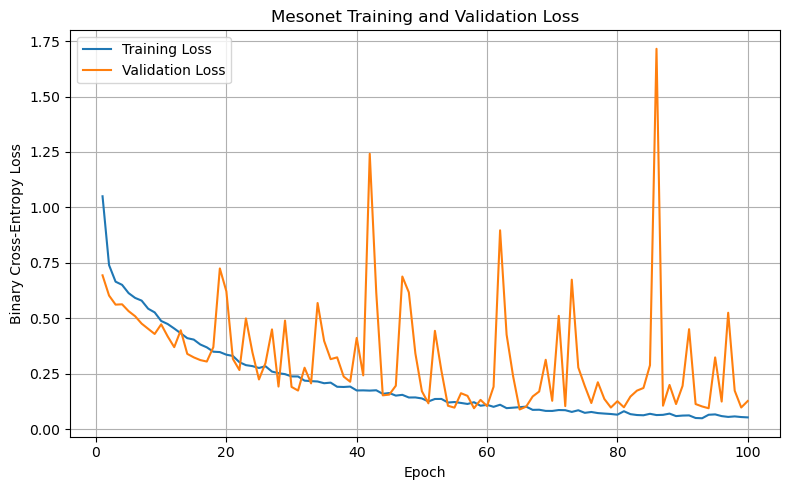

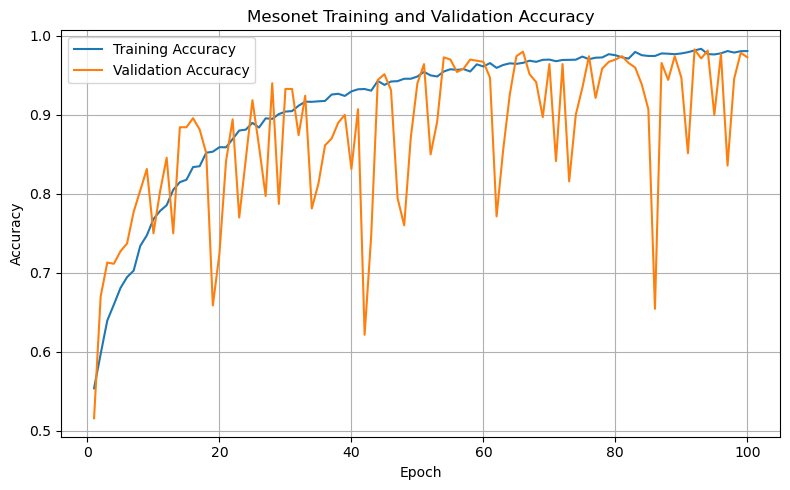

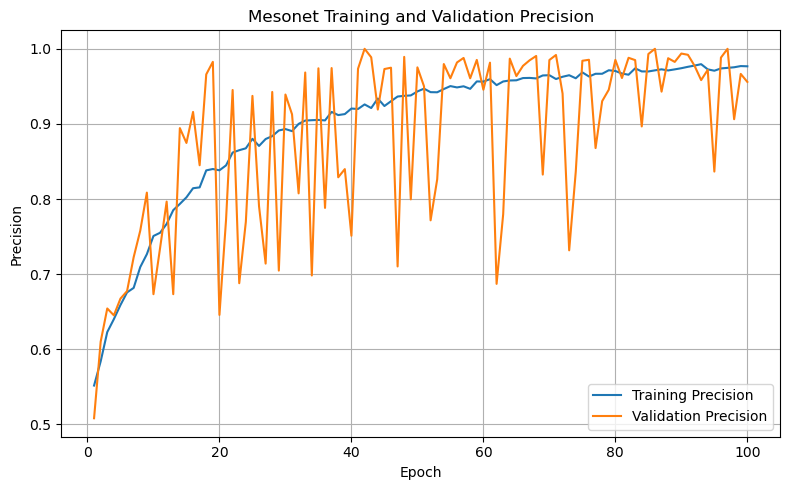

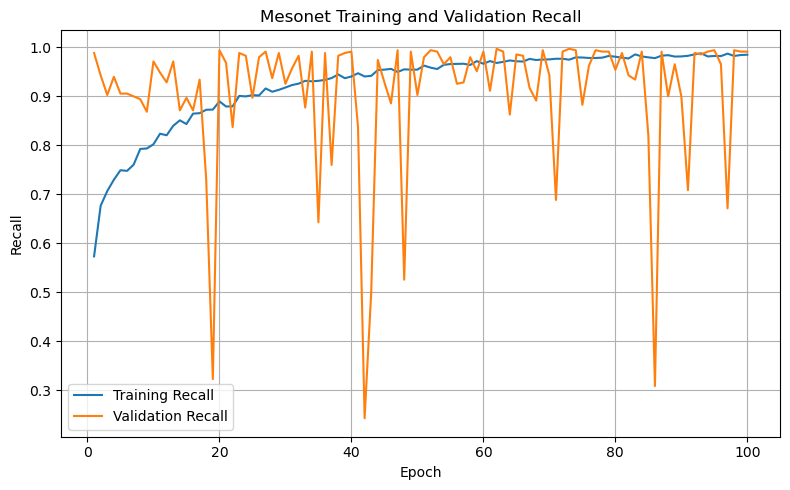

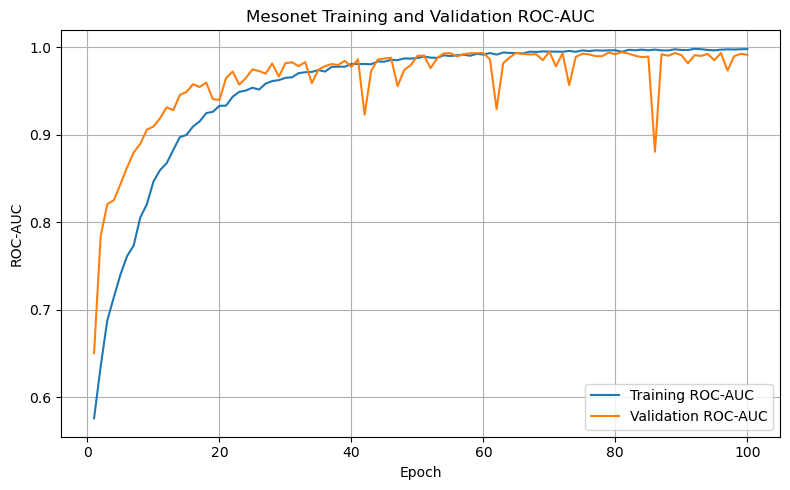

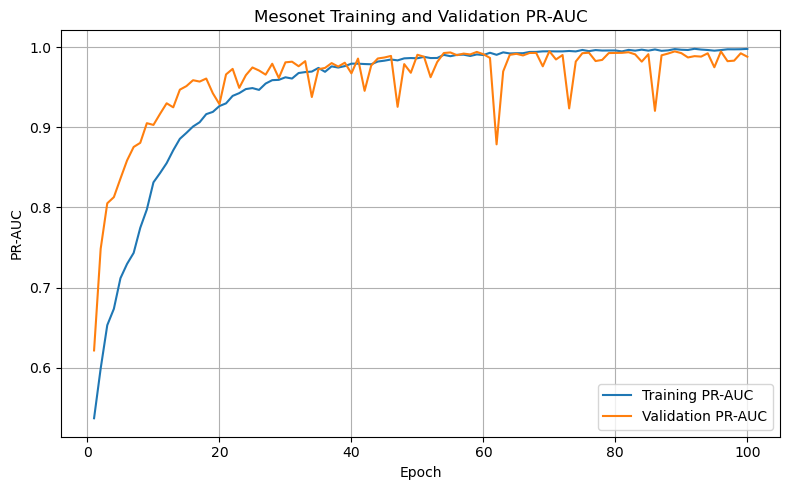

In [18]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_dfc.h5")


In [ ]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_hog),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_hog[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_hog,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_hog)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_43440\3709879675.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 0.95 seconds, 0.3151 ms/image

Starting resource run 2/5
Run 2: 0.67 seconds, 0.2249 ms/image

Starting resource run 3/5
Run 3: 0.71 seconds, 0.2354 ms/image

Starting resource run 4/5
Run 4: 0.70 seconds, 0.2323 ms/image

Starting resource run 5/5
Run 5: 0.66 seconds, 0.2194 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,0.945287,0.315096,3173.640000,2.653125,4.928125,6034.429688,6224.362891,6294.726562,189.933203,260.296875,...,7183.1875,7183.1875,0.0,0.0,61.900,75,5.17640,12.338,0.001144,1
1,0.674647,0.224882,4446.768622,2.867578,5.375000,6044.601562,6228.335449,6303.222656,183.733887,258.621094,...,7183.1875,7183.1875,0.0,0.0,51.375,81,9.18150,14.300,0.001626,2
2,0.706126,0.235375,4248.531743,3.171094,5.825000,6045.714844,6229.697754,6303.882812,183.982910,258.167969,...,7183.1875,7183.1875,0.0,0.0,44.625,82,7.86025,12.968,0.001489,3
3,0.696884,0.232295,4304.877757,2.567188,4.031250,6046.335938,6222.588379,6304.476562,176.252441,258.140625,...,7183.1875,7183.1875,0.0,0.0,51.750,87,6.32275,12.248,0.001158,4
4,0.658065,0.219355,4558.820870,3.216797,6.215625,6046.339844,6228.891113,6304.835938,182.551270,258.496094,...,7183.1875,7183.1875,0.0,0.0,51.500,81,7.05400,10.906,0.001216,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,0.736202,0.118386,0.589206,0.883198
1,latency_ms_per_image,0.245401,0.039462,0.196402,0.294399
2,throughput_images_per_s,4146.527798,557.252257,3454.607733,4838.447864
3,average_cpu_percent,2.895156,0.294320,2.529710,3.260603
4,peak_cpu_percent,5.275000,0.846243,4.224250,6.325750
5,average_ram_mb,6226.775117,3.114542,6222.907902,6230.642332
6,peak_ram_mb,6302.228906,4.238416,6296.966218,6307.491595
7,average_incremental_ram_mb,183.290742,4.870376,177.243371,189.338113
8,peak_incremental_ram_mb,258.744531,0.892168,257.636758,259.852304
9,average_gpu_memory_mb,7183.187500,0.000000,7183.187500,7183.187500



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.245 ± 0.039 (95% CI: 0.196–0.294)
peak_ram_mb: 6302.229 ± 4.238 (95% CI: 6296.966–6307.492)
peak_gpu_memory_mb: 7183.188 ± 0.000 (95% CI: 7183.188–7183.188)
average_gpu_utilization_percent: 52.230 ± 6.181 (95% CI: 44.555–59.905)
average_gpu_power_w: 7.119 ± 1.518 (95% CI: 5.234–9.004)


In [11]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_hog,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_hog,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

188/188 [==============================] - 0s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     3000
Decision threshold:         0.5000
Test loss:                  0.226982

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.939667 (93.97%)
Precision:                  0.912445 (91.24%)
Recall/Sensitivity:         0.972667 (97.27%)
F1-score:                   0.941594 (94.16%)
ROC-AUC:                    0.987768
PR-AUC:                     0.988403
Average Precision:          0.988401
EER:                        0.048333 (4.83%)
EER threshold:              0.837896

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.939667
Specificity:                0.906667
Matthews correlation:       0.881255
False-positive rate @ 0.5:  0.093333
False-negative rate @ 0.5:  0.027333

Confusion matrix
----------------------

#genralization

In [13]:
#wild deepfake on dfc
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 4s 3ms/step - loss: 1.2970 - accuracy: 0.6721 - precision: 0.7480 - recall: 0.8487 - roc_auc: 0.4439 - pr_auc: 0.7124

Test results of DFC on wild deepfake dataset (Mesonet):
loss: 1.2970
accuracy: 0.6721
precision: 0.7480
recall: 0.8487
roc_auc: 0.4439
pr_auc: 0.7124


In [15]:
#celeb on dfc
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on Celeb-DF(V2) dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



373/373 [==============================] - 2s 5ms/step - loss: 1.1300 - accuracy: 0.7589 - precision: 0.8994 - recall: 0.8258 - roc_auc: 0.4625 - pr_auc: 0.8957

Test results of DFC on Celeb-DF(V2) dataset (Mesonet):
loss: 1.1300
accuracy: 0.7589
precision: 0.8994
recall: 0.8258
roc_auc: 0.4625
pr_auc: 0.8957


In [17]:
#FF++ on hog
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of dfc on FF++ dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 1s 7ms/step - loss: 3.0019 - accuracy: 0.3988 - precision: 0.3708 - recall: 0.6363 - roc_auc: 0.4094 - pr_auc: 0.3617

Test results of dfc on FF++ dataset (Mesonet):
loss: 3.0019
accuracy: 0.3988
precision: 0.3708
recall: 0.6363
roc_auc: 0.4094
pr_auc: 0.3617


# FF++

LOAD THE DATASET

In [14]:
import os, cv2, numpy as np

FINAL_ROOT = r'D:\thesis\ff_final'

def load_split(split, cls):
    base = os.path.join(FINAL_ROOT, split, cls)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        d = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(d, f)) for f in sorted(os.listdir(d))]
        if frames:
            nested.append(frames); ids.append(vid_id)
    return nested, ids

# Main splits
ff_real_train_f, ff_real_train_ids = load_split('train', 'real')
ff_fake_train_f, ff_fake_train_ids = load_split('train', 'fake')
ff_real_val_f,   ff_real_val_ids   = load_split('val',   'real')
ff_fake_val_f,   ff_fake_val_ids   = load_split('val',   'fake')
ff_real_test_f,  ff_real_test_ids  = load_split('test',  'real')
ff_fake_test_f,  ff_fake_test_ids  = load_split('test',  'fake')

print("Reloaded main splits. Example shape:", np.shape(ff_real_train_f[0][0]))  # (160,160,3)
print("Real train videos:", len(ff_real_train_f), "| Fake train videos:", len(ff_fake_train_f))
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Combine all frames from the real and fake video groups.

    Labels:
        0 = Real
        1 = Fake
    """

    real_frames = [
        frame
        for video in real_videos
        for frame in video
        if frame is not None
    ]

    fake_frames = [
        frame
        for video in fake_videos
        for frame in video
        if frame is not None
    ]

    if not real_frames:
        raise ValueError("No real frames found.")

    if not fake_frames:
        raise ValueError("No fake frames found.")

    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training data
train_ff, train_ff_labels = combine_split(
    ff_real_train_f,
    ff_fake_train_f
)

# Validation data
val_ff, val_ff_labels = combine_split(
    ff_real_val_f,
    ff_fake_val_f
)

# Testing data
test_ff, test_ff_labels = combine_split(
    ff_real_test_f,
    ff_fake_test_f
)
print("\nTRAIN")
print("Images:", train_ff.shape)
print("Labels:", train_ff_labels.shape)
print("Real:", np.sum(train_ff_labels == 0))
print("Fake:", np.sum(train_ff_labels == 1))

print("\nVALIDATION")
print("Images:", val_ff.shape)
print("Labels:", val_ff_labels.shape)
print("Real:", np.sum(val_ff_labels == 0))
print("Fake:", np.sum(val_ff_labels == 1))

print("\nTEST")
print("Images:", test_ff.shape)
print("Labels:", test_ff_labels.shape)
print("Real:", np.sum(test_ff_labels == 0))
print("Fake:", np.sum(test_ff_labels == 1))

print("\nData types")
print("Train images:", train_ff.dtype)
print("Train labels:", train_ff_labels.dtype)

Reloaded main splits. Example shape: (160, 160, 3)
Real train videos: 517 | Fake train videos: 320

TRAIN
Images: (4595, 160, 160, 3)
Labels: (4595,)
Real: 2948
Fake: 1647

VALIDATION
Images: (948, 160, 160, 3)
Labels: (948,)
Real: 499
Fake: 449

TEST
Images: (2475, 160, 160, 3)
Labels: (2475,)
Real: 1444
Fake: 1031

Data types
Train images: uint8
Train labels: uint8


In [7]:

# Train model
history = model.fit(
    train_ff, train_ff_labels,
    validation_data=(val_ff, val_ff_labels),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
288/288 [==============================] - 6s 10ms/step - loss: 1.2257 - accuracy: 0.5654 - precision: 0.3624 - recall: 0.2799 - roc_auc: 0.4941 - pr_auc: 0.3558 - val_loss: 0.7126 - val_accuracy: 0.4895 - val_precision: 0.4533 - val_recall: 0.3786 - val_roc_auc: 0.4748 - val_pr_auc: 0.4798
Epoch 2/100
288/288 [==============================] - 3s 9ms/step - loss: 0.8013 - accuracy: 0.5880 - precision: 0.3888 - recall: 0.2611 - roc_auc: 0.5223 - pr_auc: 0.3776 - val_loss: 0.7051 - val_accuracy: 0.5264 - val_precision: 0.5000 - val_recall: 0.0022 - val_roc_auc: 0.5505 - val_pr_auc: 0.5287
Epoch 3/100
288/288 [==============================] - 3s 9ms/step - loss: 0.7430 - accuracy: 0.5848 - precision: 0.3840 - recall: 0.2623 - roc_auc: 0.5253 - pr_auc: 0.3795 - val_loss: 0.7043 - val_accuracy: 0.5264 - val_precision: 0.5000 - val_recall: 0.0022 - val_roc_auc: 0.5607 - val_pr_auc: 0.5318
Epoch 4/100
288/288 [==============================] - 3s 9ms/step - loss: 0.7193 - accura

In [8]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [9]:
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 1s 4ms/step - loss: 0.3197 - accuracy: 0.8711 - precision: 0.8648 - recall: 0.8186 - roc_auc: 0.9423 - pr_auc: 0.9218

Test results:
loss: 0.3197
accuracy: 0.8711
precision: 0.8648
recall: 0.8186
roc_auc: 0.9423
pr_auc: 0.9218


In [10]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 8.4%
RAM Used: 233.1 MB
Time Usage: 3.0 s
GPU Memory Used: 587.5 MB
Power Consumption: 93W


#save the model

In [11]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_ff_100epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_ff.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_ff_100epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


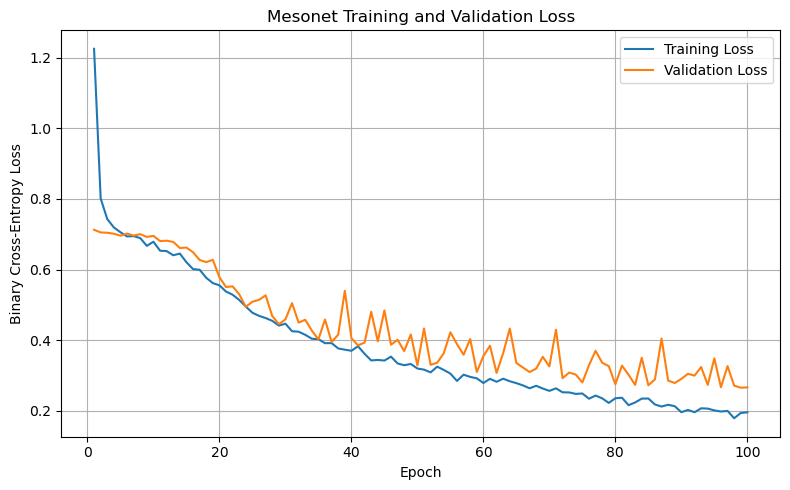

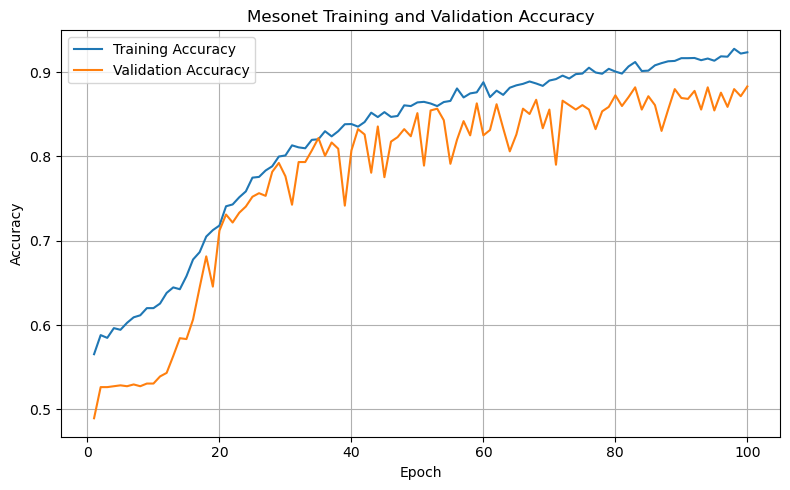

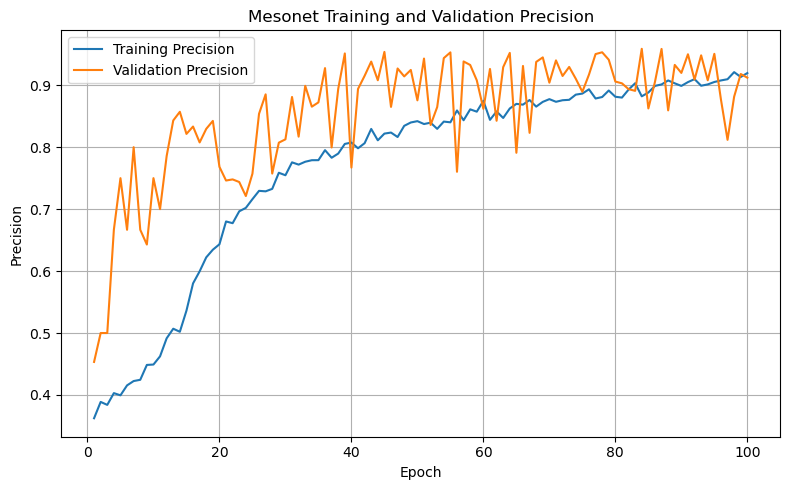

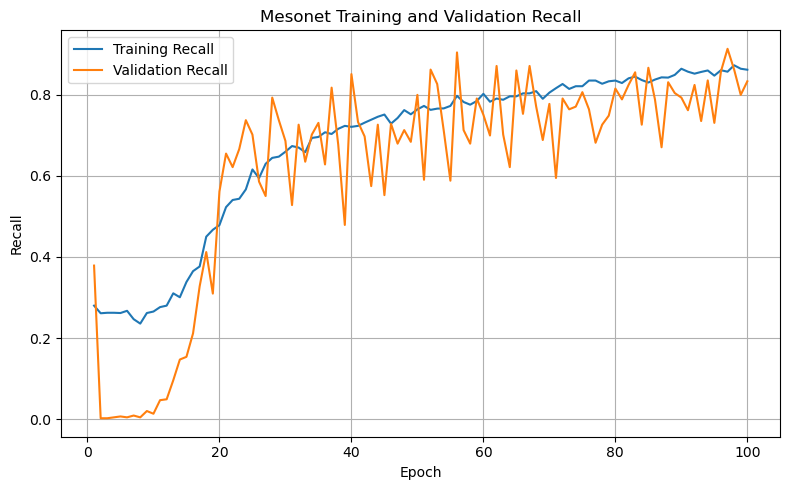

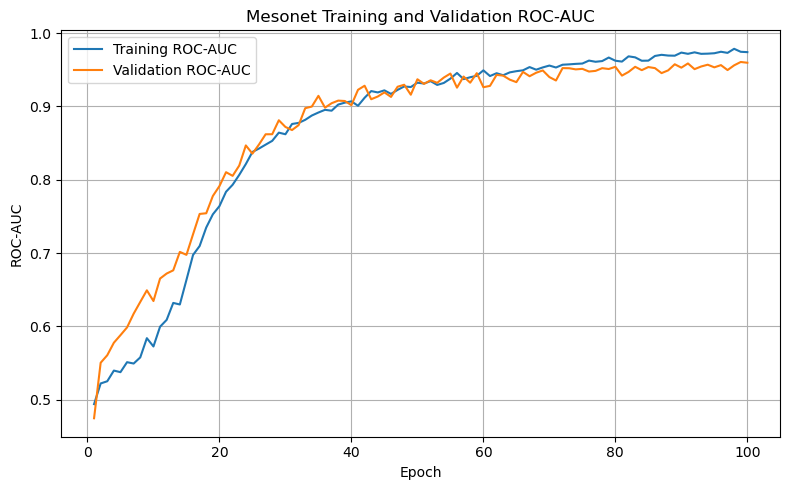

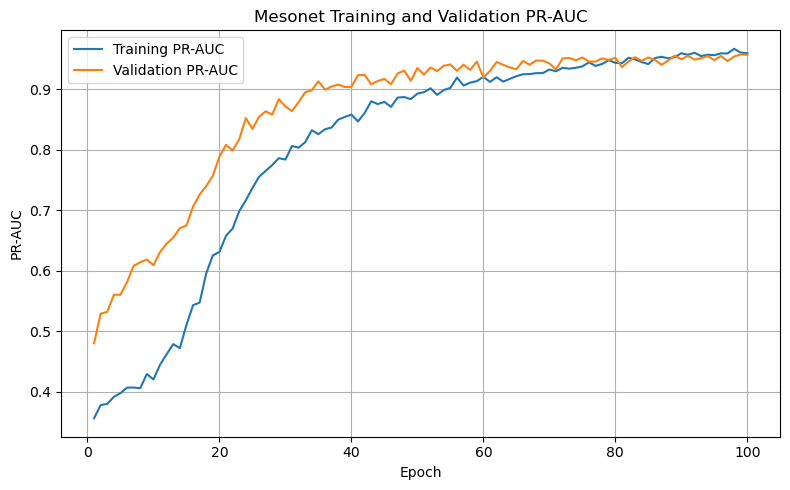

In [21]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_ff_10epochs.h5")


model = tf.keras.models.load_model(MODEL_PATH,compile=False)

In [12]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_ff),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_ff[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_ff,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_ff)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_21096\115312294.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 0.70 seconds, 0.2843 ms/image

Starting resource run 2/5
Run 2: 0.57 seconds, 0.2322 ms/image

Starting resource run 3/5
Run 3: 0.69 seconds, 0.2792 ms/image

Starting resource run 4/5
Run 4: 0.74 seconds, 0.2983 ms/image

Starting resource run 5/5
Run 5: 0.64 seconds, 0.2580 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,0.703544,0.284260,3517.903642,2.483594,4.478125,5030.140625,5177.897461,5252.761719,147.756836,222.621094,...,7183.1875,7183.1875,0.0,0.0,43.250000,94,5.414625,10.246,0.000932,1
1,0.574629,0.232173,4307.127609,2.678125,5.328125,5039.433594,5187.935826,5259.683594,148.502232,220.250000,...,7183.1875,7183.1875,0.0,0.0,48.000000,80,6.056429,10.529,0.000894,2
2,0.690996,0.279190,3581.786291,2.403125,4.031250,5040.875000,5189.059082,5261.648438,148.184082,220.773438,...,7183.1875,7183.1875,0.0,0.0,56.125000,88,4.283375,8.300,0.000700,3
3,0.738312,0.298308,3352.241783,2.783333,4.687500,5042.914062,5203.361979,5262.734375,160.447917,219.820312,...,7183.1875,7183.1875,0.0,0.0,56.555556,88,6.633222,9.455,0.001289,4
4,0.638458,0.257963,3876.526294,2.651172,4.031250,5043.218750,5196.603027,5262.921875,153.384277,219.703125,...,7183.1875,7183.1875,0.0,0.0,49.750000,81,5.995625,9.926,0.000933,5


In [13]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,0.669188,0.063874,0.589877,0.748498
1,latency_ms_per_image,0.270379,0.025808,0.238334,0.302424
2,throughput_images_per_s,3727.117124,375.552299,3260.807355,4193.426892
3,average_cpu_percent,2.599870,0.153821,2.408876,2.790863
4,peak_cpu_percent,4.511250,0.538574,3.842523,5.179977
5,average_ram_mb,5190.971475,9.605223,5179.045016,5202.897935
6,peak_ram_mb,5259.950000,4.219355,5254.710978,5265.189022
7,average_incremental_ram_mb,151.655069,5.419610,144.925734,158.384403
8,peak_incremental_ram_mb,220.633594,1.187861,219.158669,222.108518
9,average_gpu_memory_mb,7183.187500,0.000000,7183.187500,7183.187500



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.270 ± 0.026 (95% CI: 0.238–0.302)
peak_ram_mb: 5259.950 ± 4.219 (95% CI: 5254.711–5265.189)
peak_gpu_memory_mb: 7183.188 ± 0.000 (95% CI: 7183.188–7183.188)
average_gpu_utilization_percent: 50.736 ± 5.644 (95% CI: 43.728–57.744)
average_gpu_power_w: 5.677 ± 0.890 (95% CI: 4.571–6.782)


In [14]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_ff,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_ff_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

155/155 [==============================] - 0s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     2475
Decision threshold:         0.5000
Test loss:                  0.319677

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.871111 (87.11%)
Precision:                  0.864754 (86.48%)
Recall/Sensitivity:         0.818623 (81.86%)
F1-score:                   0.841056 (84.11%)
ROC-AUC:                    0.943324
PR-AUC:                     0.927109
Average Precision:          0.927145
EER:                        0.130914 (13.09%)
EER threshold:              0.420797

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.863605
Specificity:                0.908587
Matthews correlation:       0.733579
False-positive rate @ 0.5:  0.091413
False-negative rate @ 0.5:  0.181377

Confusion matrix
---------------------

#gernalization

In [16]:
#wild deepfake on ff
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 5s 5ms/step - loss: 3.3758 - accuracy: 0.2589 - precision: 0.5573 - recall: 0.0580 - roc_auc: 0.3846 - pr_auc: 0.6767

Test results of FF++ on wild deepfake dataset (Mesonet):
loss: 3.3758
accuracy: 0.2589
precision: 0.5573
recall: 0.0580
roc_auc: 0.3846
pr_auc: 0.6767


In [18]:
#celeb on ff
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on Celeb-df(v2) dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 2s 4ms/step - loss: 2.4762 - accuracy: 0.2302 - precision: 0.9819 - recall: 0.1514 - roc_auc: 0.7084 - pr_auc: 0.9539

Test results of FF++ on Celeb-df(v2) dataset (Mesonet):
loss: 2.4762
accuracy: 0.2302
precision: 0.9819
recall: 0.1514
roc_auc: 0.7084
pr_auc: 0.9539


In [20]:
#DFC on ff
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on DFC dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


188/188 [==============================] - 1s 6ms/step - loss: 1.8406 - accuracy: 0.4630 - precision: 0.4752 - recall: 0.7100 - roc_auc: 0.4271 - pr_auc: 0.4441

Test results of FF++ on DFC dataset (Mesonet):
loss: 1.8406
accuracy: 0.4630
precision: 0.4752
recall: 0.7100
roc_auc: 0.4271
pr_auc: 0.4441
